In [13]:
import numpy as np
import torch
from sbi.utils import BoxUniform
import matplotlib.pyplot as plt


def init_population(N0):
    shape = (2, 1)
    n = np.zeros(shape, dtype=int)
    n[:, 0] = N0 // 2
    w = np.ones(shape, dtype=float)
    u = np.zeros(shape, dtype=int)
    return n, w, u

def clean_arrays(n, w, u):
    idx = n > 0
    idx = idx[0, :] | idx[1, :]
    n = n[:, idx]
    w = w[:, idx]
    u = u[:, idx]
    return n, w, u

def step(n, w, u, Ub, tau, alpha, beta, N):
    x = n * w
    x /= x.sum()
    n = np.random.multinomial(N, x.reshape(-1)).reshape((2, -1))
    muts = np.random.binomial(n, [[tau * Ub], [Ub]])
    n -= muts
    mutants_shape = (2, muts.sum())
    nx = np.zeros(mutants_shape, dtype=int)
    wx = np.ones(mutants_shape, dtype=float)
    ux = np.zeros(mutants_shape, dtype=int)
    fitness_effects = 1 + np.random.gamma(shape=alpha, scale=beta, size=muts.sum())
    muts_non_zero = muts.nonzero()
    used_effects = 0
    mutant_j = 0
    for i, j, num_muts in zip(muts_non_zero[0], muts_non_zero[1], muts[muts_non_zero]):
        for effect in fitness_effects[used_effects:(used_effects + num_muts)]:
            nx[i, mutant_j] = 1
            wx[i, mutant_j] = w[i, j] * effect
            ux[i, mutant_j] = u[i, j] + 1
            mutant_j += 1
        used_effects += num_muts
    n = np.concatenate((n, nx), axis=1)
    w = np.concatenate((w, wx), axis=1)
    u = np.concatenate((u, ux), axis=1)
    return n, w, u

def calc_GFP(history):
    t = sorted(history.keys())
    arrays = (history[t_] for t_ in t)
    return np.array([n[0, :].sum() / n.sum() for n, w, _ in arrays])

def calc_wbar(history):
    t = sorted(history.keys())
    arrays = (history[t_] for t_ in t)
    return np.array([(n * w).sum() / n.sum() for n, w, _ in arrays])

def calc_ubar(history):
    t = sorted(history.keys())
    arrays = (history[t_] for t_ in t)
    return np.array([(n * u).sum() / n.sum() for n, _, u in arrays])

def simulator(theta, N0=100000, gens_per_bottle=5, total_gens=300, reps=1):
    Ub, alpha, beta = theta
    Ub = 10 ** Ub
    beta = 10 ** beta
    tau = 1
    results = []
    for _ in range(reps):
        history = {}
        n, w, u = init_population(N0)
        history[0] = (n, w, u)
        N = N0
        for t in range(1, total_gens + 1):
            if t % gens_per_bottle == 0:
                N = N0
            else:
                N *= 2
            n, w, u = step(n, w, u, Ub=Ub, tau=tau, alpha=alpha, beta=beta, N=N)
            n, w, u = clean_arrays(n, w, u)
            if t % 25 == 0:
                history[t] = (n, w, u)
        GFP = calc_GFP(history)
        wbar = calc_wbar(history)
        ubar = calc_ubar(history)
        result = np.concatenate([GFP, wbar, ubar])
        if wbar[-1] > 10:
            result = np.full_like(result, np.nan, dtype=np.float32)
        results.append(torch.tensor(result, dtype=torch.float32))
    return torch.stack(results)


# Define prior bounds
prior = BoxUniform(
    low=torch.tensor([-9.0, 0.5, -4.0]),
    high=torch.tensor([-4.0, 15.0, -1.0])
)


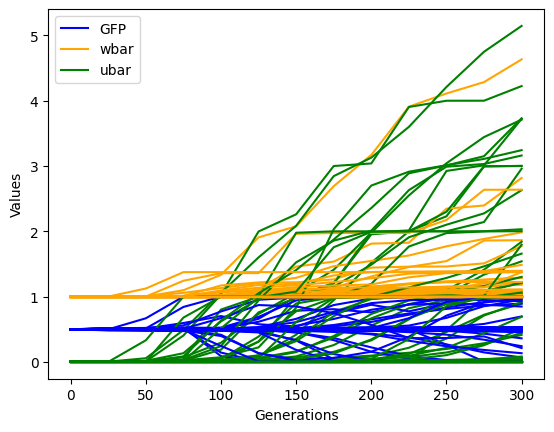

In [14]:
# Example usage:
theta = prior.sample((100,)).squeeze().numpy()

for i in range(theta.shape[0]):
    sim_results = simulator(theta[i], reps=1)
    gens = np.arange(0, 301, 25)
    GFP, wbar, ubar = np.split(sim_results.T, 3)
    plt.plot(gens, GFP, label='GFP' if i == 0 else "", color='blue')
    plt.plot(gens, wbar, label='wbar' if i == 0 else "", color='orange')
    plt.plot(gens, ubar, label='ubar' if i == 0 else "", color='green')
    plt.xlabel('Generations')
    plt.ylabel('Values')
    plt.legend()

In [15]:
# sbi imports
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

# Sample 200,000 parameter sets
num_samples = 200_000

# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)

# Check simulator, returns PyTorch simulator able to simulate batches.
sbi_simulator = process_simulator(simulator, prior, prior_returns_numpy)

# Consistency check after making ready for sbi.
check_sbi_inputs(sbi_simulator, prior)

# Generate training data
theta, x = simulate_for_sbi(sbi_simulator, proposal=prior, num_simulations=num_samples, num_workers=80)

torch.save(theta, "train_theta.pt")
torch.save(x, "train_x.pt")

  0%|          | 0/200000 [00:00<?, ?it/s]

In [18]:
# Load saved data
train_theta = torch.load("train_theta.pt")
train_x = torch.load("train_x.pt").squeeze(1)  # shape: (num_samples, reps, features) or (num_samples, features) if reps squeezed


# Train NPE
inference = NPE(prior=prior)
density_estimator = inference.append_simulations(train_theta, train_x).train()
posterior = inference.build_posterior(density_estimator)

# Save the posterior model
import pickle
with open("npe_posterior.pkl", "wb") as f:
    pickle.dump(posterior, f)

 Neural network successfully converged after 133 epochs.

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

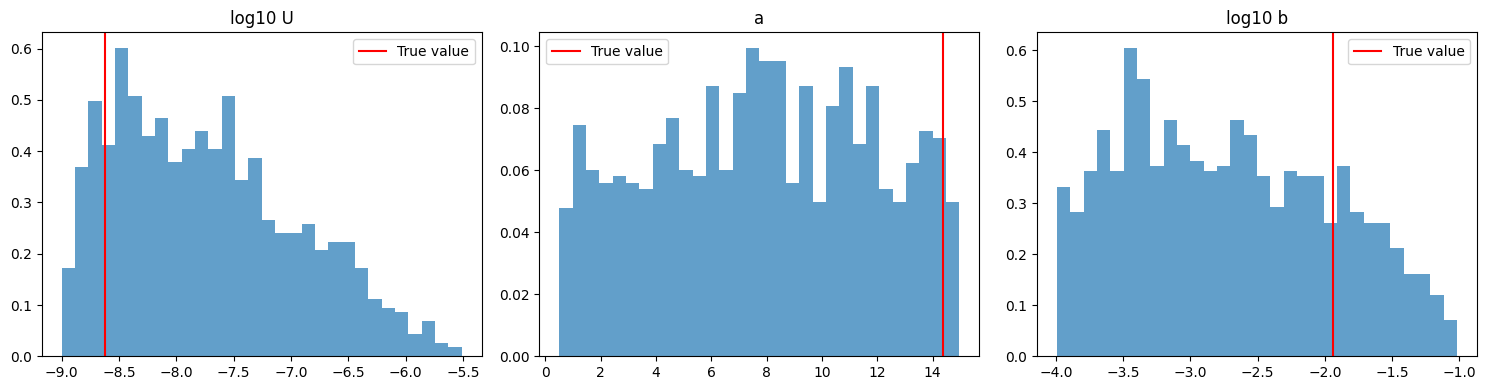

In [68]:
theta = prior.sample((1,))[0]  # Example parameters in log10 space
samples = posterior.set_default_x(simulator(theta, reps=1)).sample((1000,))
param_names = ["log10 U", "a", "log10 b"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.hist(samples[:, i].numpy(), bins=30, density=True, alpha=0.7)
    ax.axvline(theta[i], color='red', label='True value')
    ax.set_title(param_names[i])
    ax.legend()
plt.tight_layout()
plt.show()

Rejection Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]/home/jupyter-nadavbennun/Nadav/Posterior/collective_posterior/GORDO/../collective_posterior.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta, dtype=torch.float32)
/home/jupyter-nadavbennun/Nadav/Posterior/collective_posterior/GORDO/../collective_posterior.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta, dtype=torch.float32)
Rejection Sampling: 1188it [00:01, 1130.88it/s]
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values t

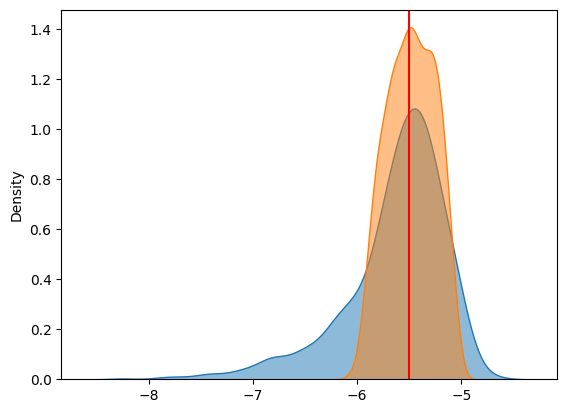

In [ ]:
import sys
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from seaborn import kdeplot

x = simulator(theta, reps=10)
op = CollectivePosterior(prior, x, posterior, 1, -10)
op.get_log_C()
samps = op.sample(1000)

param_names = ["log10 U", "a", "log10 b"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    kdeplot(samples[:, i].numpy(), fill=True, alpha=0.5, label='Posterior', ax=ax)
    kdeplot(samps[:, i].numpy(), fill=True, alpha=0.5, label='Collective', ax=ax)
    ax.axvline(theta[i], color='red', label='True value')
    ax.set_title(param_names[i])
    ax.legend()
plt.tight_layout()
plt.show()